# EDA: Default of Credit Card Clients

Клиенты кредитных карт тайваньского банка, апрель-сентябрь 2005. Таргет - дефолт по платежу в следующем месяце (октябрь).

Данные: `data/raw/credit.csv` (стадия `download` в DVC).

Описание колонок на Kaggle и UCI местами расходится с данными. Там, где они спорят, я опираюсь на ответ автора датасета, который один из участников выложил в [обсуждении на Kaggle](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset/discussion/34608). Что именно автор считает дефолтом, там не сказано. В обсуждениях сходятся на том, что это пропуск платежа в октябре 2005, то есть просрочка, а не списанный долг.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import os
os.chdir('..')

from src.features.build_features import AGE_LABELS, add_features

df = pd.read_csv('data/raw/credit.csv')
df = df.rename(columns={'PAY_0': 'PAY_1', 'default payment next month': 'default'})
df.shape

(30000, 25)

In [2]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
print('пропуски:', df.isna().sum().sum())
print('дубликаты (без ID):', df.drop(columns='ID').duplicated().sum())
df.dtypes.value_counts()

пропуски: 0
дубликаты (без ID): 35


int64    25
Name: count, dtype: int64

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_1,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


## Таргет

In [5]:
print(df['default'].value_counts())
df['default'].mean()

default
0    23364
1     6636
Name: count, dtype: int64


np.float64(0.2212)

Дефолтов около 22%, дисбаланс умеренный. Accuracy тут почти ничего не скажет: модель, которая всем отвечает «не дефолт», уже получит 78%. Поэтому основной метрикой беру ROC-AUC, а precision, recall и F1 смотрю при пороге 0.5. Сплит стратифицирую.

## Категориальные признаки

In [6]:
for col in ['SEX', 'EDUCATION', 'MARRIAGE']:
    print(df.groupby(col)['default'].agg(['count', 'mean']).round(3), '\n')

     count   mean
SEX              
1    11888  0.242
2    18112  0.208 

           count   mean
EDUCATION              
0             14  0.000
1          10585  0.192
2          14030  0.237
3           4917  0.252
4            123  0.057
5            280  0.064
6             51  0.157 

          count   mean
MARRIAGE              
0            54  0.093
1         13659  0.235
2         15964  0.209
3           323  0.260 



По карточке на Kaggle EDUCATION: 1 - graduate school, 2 - university, 3 - high school, 4 - others, 5 и 6 - unknown, а 0 там нет вовсе. Автор датасета уточнил, что 0, 4, 5 и 6 - это others, так что в `add_features` я сливаю их в 4. Таких строк 468 из 30 000, дефолтов у них 7%.

С MARRIAGE интереснее. На Kaggle написано, что 3 - others, а по словам автора 3 - это divorce, а others - это 0. По данным группы и правда разные: у нуля 9% дефолтов, у тройки 26%. Сначала я сливал 0 в 3, после письма автора оставил 0 отдельной категорией.

## Возраст и кредитный лимит

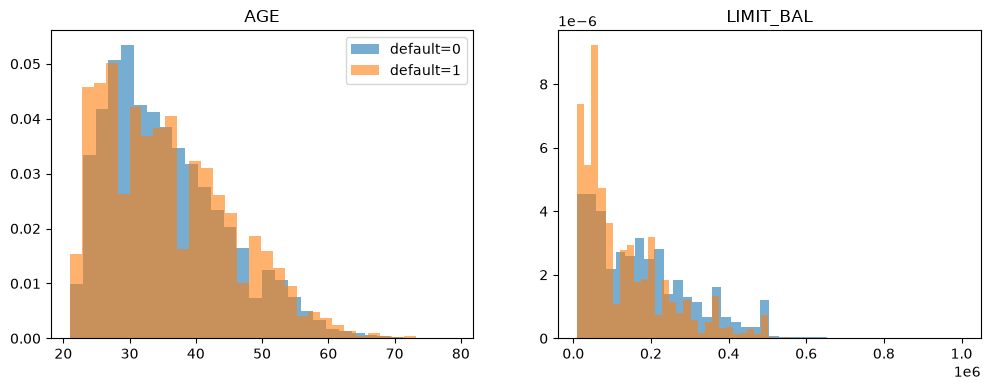

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for target, g in df.groupby('default'):
    axes[0].hist(g['AGE'], bins=30, alpha=0.6, density=True, label=f'default={target}')
    axes[1].hist(g['LIMIT_BAL'], bins=40, alpha=0.6, density=True, label=f'default={target}')
axes[0].set_title('AGE')
axes[1].set_title('LIMIT_BAL')
axes[0].legend()
plt.show()

In [8]:
feat = add_features(df)
feat.groupby('AGE_BIN')['default'].agg(['count', 'mean']).reindex(AGE_LABELS).round(3)

,count,mean
AGE_BIN,,
<25,2685,0.272
25-34,13011,0.203
35-44,9018,0.219
45-54,4233,0.239
55+,1053,0.267


## История платежей

Колонки с `PAY_1` по `PAY_6` - статус платежа с сентября по апрель. В карточке на Kaggle нет значений -2 и 0, полная шкала есть в ответе автора: -2 - картой не пользовались, -1 - долг погашен полностью, 0 - внесён минимальный платёж (револьверный кредит), от 1 до 9 - задержка в месяцах. Просрочка - это только положительные значения, так её и считает `PAY_DELAY_COUNT`.

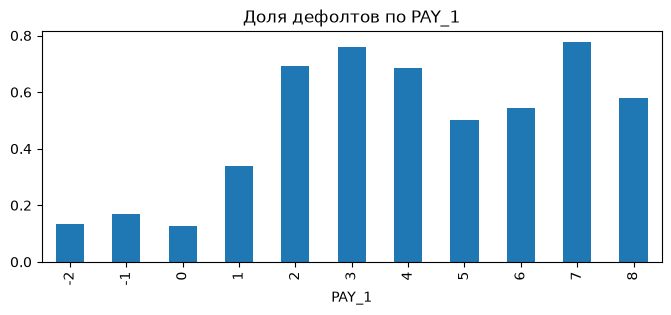

,count,mean
PAY_1,,
-2,2759,0.132
-1,5686,0.168
0,14737,0.128
1,3688,0.339
2,2667,0.691
3,322,0.758
4,76,0.684
5,26,0.500
6,11,0.545


In [9]:
rate = df.groupby('PAY_1')['default'].agg(['count', 'mean'])
ax = rate['mean'].plot.bar(figsize=(8, 3), title='Доля дефолтов по PAY_1')
plt.show()
rate.round(3)

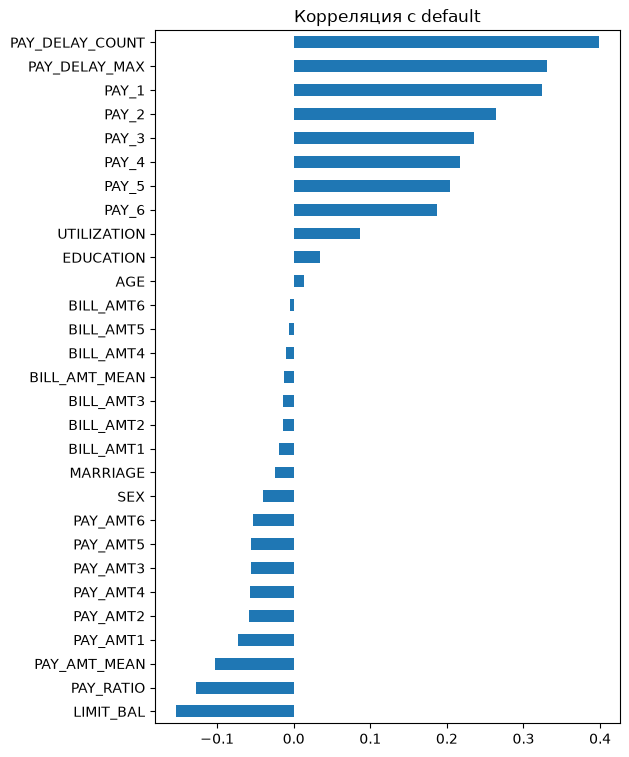

In [10]:
corr = feat.drop(columns=['ID', 'AGE_BIN']).corr()['default'].drop('default')
corr.sort_values().plot.barh(figsize=(6, 9), title='Корреляция с default')
plt.show()

In [11]:
bill = df[[f'BILL_AMT{i}' for i in range(1, 7)]]
bill.corr().round(2)

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
BILL_AMT1,1.00,0.95,0.89,0.86,0.83,0.80
BILL_AMT2,0.95,1.00,0.93,0.89,0.86,0.83
BILL_AMT3,0.89,0.93,1.00,0.92,0.88,0.85
BILL_AMT4,0.86,0.89,0.92,1.00,0.94,0.90
BILL_AMT5,0.83,0.86,0.88,0.94,1.00,0.95
BILL_AMT6,0.80,0.83,0.85,0.90,0.95,1.00


## Странности в данных

In [12]:
pay = [f'PAY_{i}' for i in range(1, 7)]
bills = [f'BILL_AMT{i}' for i in range(1, 7)]
print('статус 1 по месяцам:', {c: int((df[c] == 1).sum()) for c in pay})
jump = pd.concat([(df[pay[k]] >= 2) & (df[pay[k + 1]] <= 0) for k in range(5)], axis=1)
print('переходов в статус 2 сразу после месяца без долга:', int(jump.values.sum()), '| строк:', int(jump.any(axis=1).sum()))
print('по месяцам:', {pay[k]: int(jump[k].sum()) for k in range(5)})
print('во что переходят:', pd.concat([df.loc[jump[k], pay[k]] for k in range(5)]).value_counts().to_dict())
print('счёт больше лимита хотя бы раз:', (df[bills].max(axis=1) > df['LIMIT_BAL']).mean().round(3))
print('отрицательный счёт в сентябре:', (df['BILL_AMT1'] < 0).mean().round(3))

статус 1 по месяцам: {'PAY_1': 3688, 'PAY_2': 28, 'PAY_3': 4, 'PAY_4': 2, 'PAY_5': 0, 'PAY_6': 0}
переходов в статус 2 сразу после месяца без долга: 6209 | строк: 5948
по месяцам: {'PAY_1': 991, 'PAY_2': 1479, 'PAY_3': 1623, 'PAY_4': 1254, 'PAY_5': 862}
во что переходят: {2: 6209}
счёт больше лимита хотя бы раз: 0.131
отрицательный счёт в сентябре: 0.02


Статус 1 (задержка на месяц) встречается почти только в сентябре: 3688 раз, а в остальных месяцах 28, 4, 2, 0 и 0. При этом часто бывает, что в предыдущем месяце долга не было (статус -2, -1 или 0), а в следующем сразу стоит 2. За один месяц просрочка может вырасти максимум на месяц, так что настоящей двухмесячной задержкой эта двойка быть не может. Таких переходов 6209 в 5948 строках, все они ведут ровно в 2, и есть они в каждом месяце, в сентябре тоже (991). Похоже, первую просрочку часто записывали сразу как 2, а до сентября почти всегда, поэтому `PAY_1` и `PAY_2` по смыслу не совсем одинаковые признаки. Исправлять эти значения я не стал: восстановить настоящую задержку по этим данным нельзя.

В 13% строк счёт хотя бы раз превышал лимит, в 2% счёт за сентябрь отрицательный. Для кредиток это бывает: проценты и штрафы выводят долг за лимит, а переплата даёт отрицательный баланс.

## Один клиент в двух строках

В обсуждениях на Kaggle заметили, что часть строк - это один и тот же клиент, снятый с разницей в месяц: история одной строки совпадает с историей другой со сдвигом. Проверяю так: у пары должны быть одинаковые демография и пять месяцев статусов, счетов и платежей. Пары, где все счета нулевые или одинаковые, выкидываю, такие совпадения бывают случайно.

In [13]:
demo = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE']
amts = [f'PAY_AMT{i}' for i in range(1, 7)]
key = demo + [f'k{i}' for i in range(15)]
earlier = df[['ID'] + demo + pay[:5] + bills[:5] + amts[:5]].set_axis(['ID'] + key, axis=1)
later = df[['ID'] + demo + pay[1:] + bills[1:] + amts[1:]].set_axis(['ID_later'] + key, axis=1)
twins = earlier.merge(later, on=key).query('ID != ID_later')
bill_keys = [f'k{i}' for i in range(5, 10)]
twins = twins[(twins[bill_keys].abs().sum(axis=1) > 0) & (twins[bill_keys].nunique(axis=1) > 1)]
print('пар:', len(twins), '| строк в них:', len(set(twins.ID) | set(twins.ID_later)))
(twins.ID_later - twins.ID).describe().round()

пар: 1037 | строк в них: 2074


count     1037.0
mean     15050.0
std       6213.0
min        879.0
25%      10648.0
50%      15012.0
75%      19444.0
max      29365.0
dtype: float64

Таких пар 1037, это около 7% строк. У более позднего снимка ID всегда больше, в среднем на 15 000, но разброс большой: от 879 до 29 365. При случайном сплите часть пар попадёт одновременно в train и test, а это утечка. Насколько она влияет на метрики, проверяю в конце ноутбука на обученной модели.

## Новые признаки

In [14]:
feat.groupby('PAY_DELAY_COUNT')['default'].agg(['count', 'mean']).round(3)

,count,mean
PAY_DELAY_COUNT,,
0,19931,0.117
1,4426,0.298
2,1899,0.388
3,1154,0.509
4,951,0.573
5,298,0.574
6,1341,0.703


In [15]:
new = ['PAY_DELAY_MAX', 'PAY_DELAY_COUNT', 'BILL_AMT_MEAN', 'PAY_AMT_MEAN', 'UTILIZATION', 'PAY_RATIO']
print('пропуски в PAY_RATIO:', feat['PAY_RATIO'].isna().mean().round(3))
feat[new + ['default']].corr()['default'].round(3)

пропуски в PAY_RATIO: 0.106


PAY_DELAY_MAX      0.331
PAY_DELAY_COUNT    0.398
BILL_AMT_MEAN     -0.013
PAY_AMT_MEAN      -0.102
UTILIZATION        0.086
PAY_RATIO         -0.127
default            1.000
Name: default, dtype: float64

## Выводы

- 30 000 строк, все признаки целочисленные, пропусков нет. 35 полных дубликатов (без учёта ID) удаляю в `clean()`.
- Дефолтов 22%, так что главная метрика у меня ROC-AUC, а сплит стратифицированный.
- Сильнее всего на дефолт влияет история платежей. Если в сентябре платёж задержан на два месяца и больше, дефолтов около 70%. У тех, кто платит вовремя, их 13-17%.
- Агрегат `PAY_DELAY_COUNT` (в скольких месяцах из шести была просрочка) коррелирует с таргетом сильнее любого исходного признака, 0.40. Без просрочек дефолтов 12%, при шести просрочках 70%.
- С возрастом картина U-образная. Меньше всего дефолтов в группе 25-34 (20%), больше всего у тех, кому меньше 25 или 55 и больше (27%). Поэтому кроме самого `AGE` в модель идёт `AGE_BIN`.
- Чем ниже кредитный лимит, тем выше риск.
- Колонки с `BILL_AMT1` по `BILL_AMT6` сильно коррелируют между собой (0.8-0.95). Логистической регрессии такая мультиколлинеарность мешает, поэтому в сетке есть регуляризация через `C`. Деревьям это не мешает.
- EDUCATION 0, 5 и 6 по ответу автора сливаю с others (4). MARRIAGE 0 оставляю отдельно: это others, а 3 означает divorce.
- `PAY_RATIO` не определён у 10.6% клиентов: счёт за август у них нулевой или отрицательный. Эти NaN заполняет `SimpleImputer` в пайплайне.
- Около 7% строк - тот же клиент со сдвигом на месяц. Проверка ниже показывает, что на метрики модели это почти не влияет.

## Проверка утечки после обучения

Эта ячейка нужна после `dvc repro`: она берёт тестовую выборку и обученную модель и сравнивает ROC-AUC на всём тесте и на тесте без строк, у которых «двойник» попал в train.

In [16]:
import joblib
from sklearn.metrics import roc_auc_score

cols = [c for c in df.columns if c != 'ID']
ids = df.drop_duplicates(subset=cols)
test = pd.read_csv('data/processed/test.csv').merge(ids, on=cols)
train_ids = set(pd.read_csv('data/processed/train.csv').merge(ids, on=cols).ID)
partner = dict(zip(twins.ID, twins.ID_later)) | dict(zip(twins.ID_later, twins.ID))
leak = test.ID.map(partner).isin(train_ids)

model = joblib.load('models/model.joblib')
proba = model.predict_proba(test.drop(columns=['ID', 'default']))[:, 1]
y = test['default']
print('строк теста с двойником в train:', leak.sum(), 'из', len(test))
print('ROC-AUC весь тест:', round(roc_auc_score(y, proba), 4))
print('ROC-AUC без двойников:', round(roc_auc_score(y[~leak], proba[~leak]), 4))
print('ROC-AUC только двойники:', round(roc_auc_score(y[leak], proba[leak]), 4))

строк теста с двойником в train: 346 из 5993
ROC-AUC весь тест: 0.7791
ROC-AUC без двойников: 0.7798
ROC-AUC только двойники: 0.767


Двойник в train есть у 346 тестовых строк из 5993. Без них ROC-AUC 0.7798, на всём тесте 0.7791, а на самих двойниках модель работает даже хуже, 0.767. Получается, утечка метрики не завышает: деревья не запоминают строки, сдвинутые на месяц. Поэтому делить выборку по группам клиентов я не стал.